Detected 356 1-hour volume breakouts


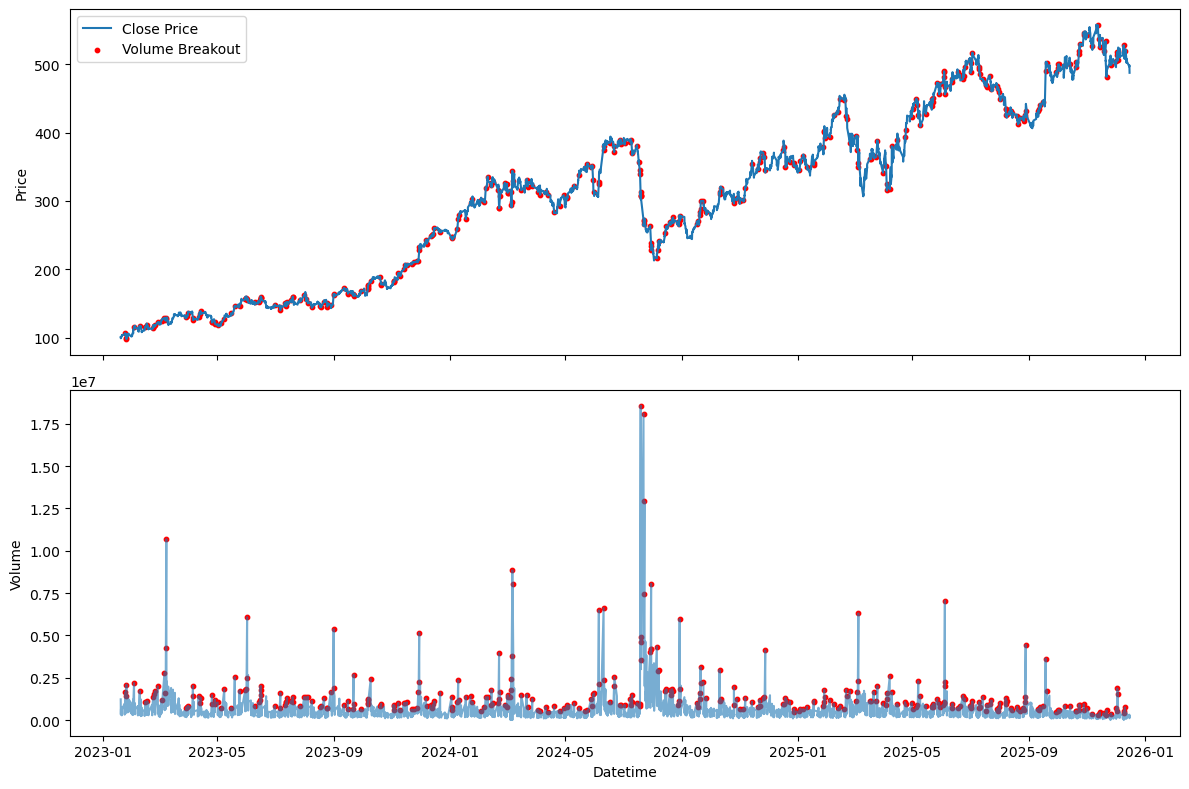

In [39]:
import pandas as pd
from stock import Stock
from analyzer import VolumeAnalyzer
from plotting import plot_volume_breakouts

# Load 1-hour intraday data
df = pd.read_csv("data/sample_stock.csv")

# Initialize stock object
stock = Stock(df, symbol="CRWD")

# Initialize volume analyzer (rolling scanner)
analyzer = VolumeAnalyzer(
    stock,
    window=20, # rolling window (20 hours)
    multiplier=2.0 # baseline volume spike threshold
)

# Detect volume breakouts
breakouts = analyzer.detect_breakouts()

print(f"Detected {len(breakouts)} 1-hour volume breakouts")

# Plot detected breakouts
plot_volume_breakouts(stock, breakouts)

In [43]:
import pandas as pd
import numpy as np

# Copy stock data to prevent tampering the original
data = stock.data.copy()

# Convert timestamps to NY (est) time for trading session calcs (NY session is 9:30am to 4:00pm)
data["Datetime"] = data["Datetime"].dt.tz_convert("America/New_York")

# Reset index to ensure consistent row-based access
data = data.reset_index(drop=True)

# Number of trading days to hold a long position after a breakout
HOLD_DAYS = 16  # best realistic length to hold for significant profit (tested on range of 1h to 20d)

# Store trade results
results = []

# Iterate through detected breakouts
for idx in breakouts.index:
    # Need a previous bar to determine breakout direction
    if idx == 0:
        continue

    entry_row = data.loc[idx]
    prev_row = data.loc[idx - 1]
    entry_time = entry_row["Datetime"]
    entry_price = entry_row["Close"]
    prev_price = prev_row["Close"]

    # Since market trends up, only enter long positions (ignore bearish breakouts)
    if entry_price <= prev_price:
        continue

    # Define exit time after 16 business days
    exit_time = entry_time + pd.offsets.BDay(HOLD_DAYS)

    # Find first available bar after the exit time
    future_data = data[data["Datetime"] >= exit_time]

    # Skip trade if no future data exists
    if future_data.empty:
        continue

    exit_row = future_data.iloc[0]
    exit_price = exit_row["Close"]

    # Calculate profit (1 share for simplicity, so personal result would be a multiplier)
    profit = exit_price - entry_price

    # Store trade result
    results.append({"EntryTime": entry_time,
                    "ExitTime": exit_row["Datetime"],
                    "EntryPrice": entry_price,
                    "ExitPrice": exit_price,
                    "Profit": profit})

# Convert results list to dataframe
results_df = pd.DataFrame(results)

# Compute final performance stats
num_trades = len(results_df)
win_rate = (results_df["Profit"] > 0).mean()
avg_profit = results_df["Profit"].mean()
total_profit = results_df["Profit"].sum()

# Show result summary
print("Long-Only Volume Breakout Strategy (16-Day Hold)")
print("------------------------------------------------")
print(f"Number of trades: {num_trades}")
print(f"Win rate: {win_rate:.2%}")
print(f"Average profit per trade: {avg_profit:.2f}")
print(f"Total profit (1 share per trade): {total_profit:.2f}")

# Display trade data
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
results_df

Long-Only Volume Breakout Strategy (16-Day Hold)
------------------------------------------------
Number of trades: 191
Win rate: 67.02%
Average profit per trade: 11.14
Total profit (1 share per trade): 2127.17


,EntryTime,ExitTime,EntryPrice,ExitPrice,Profit
0,2023-01-25 10:30:00-05:00,2023-02-16 10:30:00-05:00,98.605003,117.735001,19.129997
1,2023-02-02 09:30:00-05:00,2023-02-24 09:30:00-05:00,116.010101,117.669998,1.659897
2,2023-02-08 09:30:00-05:00,2023-03-02 09:30:00-05:00,117.449997,119.935898,2.485901
3,2023-02-14 09:30:00-05:00,2023-03-08 09:30:00-05:00,116.110001,126.760002,10.650001
4,2023-02-22 09:30:00-05:00,2023-03-16 09:30:00-04:00,114.339996,130.470001,16.130005
5,2023-02-24 09:30:00-05:00,2023-03-20 09:30:00-04:00,117.669998,132.245193,14.575195
6,2023-02-27 09:30:00-05:00,2023-03-21 09:30:00-04:00,122.349998,132.785095,10.435097
7,2023-03-03 09:30:00-05:00,2023-03-27 09:30:00-04:00,124.462196,131.786194,7.323997
8,2023-03-06 09:30:00-05:00,2023-03-28 09:30:00-04:00,128.869995,129.755005,0.885010
9,2023-03-08 09:30:00-05:00,2023-03-30 09:30:00-04:00,126.760002,131.815002,5.055000
